In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)

In [2]:
df = pd.read_csv('../data/AirQualityUCI.csv', sep=';', decimal=',')

# Drop the two junk trailing columns
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

print("Shape after dropping junk columns:", df.shape)
df.dtypes

Shape after dropping junk columns: (9471, 15)


Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

In [3]:

print("Duplicate rows:", df.duplicated().sum())


print("Fully-empty rows:", df.isna().all(axis=1).sum())


df = df.dropna(how='all')
print("Shape after dropping empty rows:", df.shape)

Duplicate rows: 113
Fully-empty rows: 114
Shape after dropping empty rows: (9357, 15)


In [4]:

time_fixed = df['Time'].str.replace('.', ':', regex=False)

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + time_fixed, format='%d/%m/%Y %H:%M:%S')

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['datetime'].dt.dayofweek >= 5

df[['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend']].head()

,datetime,hour,day,month,weekday,is_weekend
0,2004-03-10 18:00:00,18,10,3,Wednesday,False
1,2004-03-10 19:00:00,19,10,3,Wednesday,False
2,2004-03-10 20:00:00,20,10,3,Wednesday,False
3,2004-03-10 21:00:00,21,10,3,Wednesday,False
4,2004-03-10 22:00:00,22,10,3,Wednesday,False


In [5]:
print("Is already sorted by time:", df['datetime'].is_monotonic_increasing)

df = df.sort_values('datetime').reset_index(drop=True)
print("Date range:", df['datetime'].min(), "to", df['datetime'].max())
print("Total days covered:", (df['datetime'].max() - df['datetime'].min()).days)

Is already sorted by time: True
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Total days covered: 389


In [6]:

rename_map = {
    'CO(GT)': 'CO_GT', 'PT08.S1(CO)': 'PT08_S1_CO', 'NMHC(GT)': 'NMHC_GT',
    'C6H6(GT)': 'C6H6_GT', 'PT08.S2(NMHC)': 'PT08_S2_NMHC', 'NOx(GT)': 'NOx_GT',
    'PT08.S3(NOx)': 'PT08_S3_NOx', 'NO2(GT)': 'NO2_GT', 'PT08.S4(NO2)': 'PT08_S4_NO2',
    'PT08.S5(O3)': 'PT08_S5_O3', 'T': 'Temperature', 'RH': 'RelativeHumidity', 'AH': 'AbsoluteHumidity'
}
df = df.rename(columns=rename_map)

numeric_cols = list(rename_map.values())


sentinel_counts = (df[numeric_cols] == -200).sum().sort_values(ascending=False)
sentinel_counts

NMHC_GT             8443
CO_GT               1683
NO2_GT              1642
NOx_GT              1639
PT08_S1_CO           366
PT08_S2_NMHC         366
C6H6_GT              366
PT08_S3_NOx          366
PT08_S4_NO2          366
PT08_S5_O3           366
Temperature          366
RelativeHumidity     366
AbsoluteHumidity     366
dtype: int64

In [7]:
df[numeric_cols] = df[numeric_cols].replace(-200, np.nan)


df[numeric_cols].isna().sum().sort_values(ascending=False)

NMHC_GT             8443
CO_GT               1683
NO2_GT              1642
NOx_GT              1639
PT08_S1_CO           366
PT08_S2_NMHC         366
C6H6_GT              366
PT08_S3_NOx          366
PT08_S4_NO2          366
PT08_S5_O3           366
Temperature          366
RelativeHumidity     366
AbsoluteHumidity     366
dtype: int64

In [8]:
# Drop NMHC_GT - too sparse (90% missing) to impute credibly
df = df.drop(columns=['NMHC_GT'])
clean_cols = [c for c in numeric_cols if c != 'NMHC_GT']

# Time-based interpolation, but only across small gaps (max 6 hours)
# Longer gaps get a fallback below rather than stretching interpolation too far
df = df.set_index('datetime')
for col in clean_cols:
    df[col] = df[col].interpolate(method='time', limit=6, limit_direction='both')
df = df.reset_index()

print("Remaining missing after interpolation:")
print(df[clean_cols].isna().sum().sort_values(ascending=False))

Remaining missing after interpolation:
CO_GT               1181
NO2_GT              1064
NOx_GT              1062
PT08_S1_CO           240
PT08_S2_NMHC         240
C6H6_GT              240
PT08_S3_NOx          240
PT08_S4_NO2          240
PT08_S5_O3           240
Temperature          240
RelativeHumidity     240
AbsoluteHumidity     240
dtype: int64


In [9]:
for col in clean_cols:
    if df[col].isna().any():
        hourly_median = df.groupby('hour')[col].transform('median')
        df[col] = df[col].fillna(hourly_median)

print("Remaining missing after fallback:", df[clean_cols].isna().sum().sum())

Remaining missing after fallback: 0


In [10]:
stats_rows = []
for col in clean_cols:
    values = df[col].dropna().to_numpy()
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = int(((df[col] < lower_bound) | (df[col] > upper_bound)).sum())

    stats_rows.append({
        'column': col,
        'mean': np.mean(values),
        'median': np.median(values),
        'std': np.std(values, ddof=1),
        'p10': np.percentile(values, 10),
        'p90': np.percentile(values, 90),
        'iqr_lower_bound': lower_bound,
        'iqr_upper_bound': upper_bound,
        'n_outliers': n_outliers
    })

stats_table = pd.DataFrame(stats_rows)
stats_table.round(2)

,column,mean,median,std,p10,p90,iqr_lower_bound,iqr_upper_bound,n_outliers
0,CO_GT,2.11,1.80,1.40,0.60,3.91,-1.45,5.35,301
1,PT08_S1_CO,1100.08,1067.00,215.35,852.00,1408.00,501.50,1665.50,125
2,C6H6_GT,10.11,8.30,7.44,2.50,20.30,-9.75,28.25,249
3,PT08_S2_NMHC,940.46,912.00,266.12,621.00,1304.00,164.50,1688.50,68
4,NOx_GT,234.56,177.00,200.02,53.43,504.40,-201.50,594.50,619
5,PT08_S3_NOx,834.65,803.00,253.84,538.00,1150.00,202.00,1426.00,248
6,NO2_GT,110.54,109.00,46.36,55.00,172.00,-15.50,228.50,152
7,PT08_S4_NO2,1456.13,1465.00,341.39,990.00,1886.00,597.50,2305.50,122
8,PT08_S5_O3,1024.90,966.00,396.77,549.60,1586.40,-70.50,2077.50,100
9,Temperature,18.31,17.70,8.73,7.00,30.10,-6.30,42.50,9


In [11]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df['pollution_index'] = (
    normalize(df['CO_GT']) + normalize(df['NOx_GT']) + normalize(df['NO2_GT'])
) / 3

df['pollution_index'].describe()

count    9357.000000
mean        0.216180
std         0.119168
min         0.005783
25%         0.128216
50%         0.198889
75%         0.275832
max         0.873483
Name: pollution_index, dtype: float64

In [12]:
valid_rows = df[['PT08_S1_CO', 'CO_GT']].dropna()
sensor_reliability_ratio = valid_rows['PT08_S1_CO'] / valid_rows['CO_GT'].replace(0, np.nan)

print(sensor_reliability_ratio.describe())

count     9357.000000
mean       806.852677
std        825.227553
min        129.302326
25%        429.642857
50%        593.888889
75%        902.500000
max      11270.000000
dtype: float64


In [13]:
hourly_co = df.groupby('hour')['CO_GT'].mean()
hourly_co

hour
0     1.751376
1     1.431358
2     1.061983
3     0.877823
4     0.789508
5     0.738307
6     0.949968
7     1.763534
8     2.818383
9     2.959632
10    2.553262
11    2.264474
12    2.181526
13    2.225947
14    2.148806
15    2.076039
16    2.265543
17    2.787927
18    3.399032
19    3.687005
20    3.426663
21    2.563176
22    1.961115
23    1.851790
Name: CO_GT, dtype: float64

In [14]:
monthly_co = df.groupby('month')['CO_GT'].mean()
monthly_co

month
1     2.017669
2     2.080506
3     2.102552
4     2.101549
5     1.898185
6     1.880625
7     1.822715
8     1.482863
9     2.163889
10    2.395430
11    2.705347
12    2.628635
Name: CO_GT, dtype: float64

In [15]:
no2_pivot = pd.pivot_table(df, values='NO2_GT', index='hour', columns='is_weekend', aggfunc='mean')
no2_pivot.columns = ['Weekday', 'Weekend']
no2_pivot.head(10)

,Weekday,Weekend
hour,,
0,97.856432,114.114336
1,84.130269,101.006971
2,69.713285,86.517219
3,62.189783,77.182965
4,55.929700,68.154283
5,60.556194,61.493586
6,75.215521,65.359675
7,101.388923,78.346607
8,130.972879,94.171286


In [16]:
daily_co = df.set_index('datetime')['CO_GT'].resample('D').mean()
daily_co.head()

datetime
2004-03-10    1.966667
2004-03-11    2.172917
2004-03-12    2.756250
2004-03-13    2.639583
2004-03-14    2.441667
Freq: D, Name: CO_GT, dtype: float64

In [17]:
corr_matrix = df[clean_cols].corr()
corr_matrix.round(2)

,CO_GT,PT08_S1_CO,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,Temperature,RelativeHumidity,AbsoluteHumidity
CO_GT,1.00,0.82,0.86,0.85,0.79,-0.67,0.70,0.59,0.80,0.05,-0.00,0.04
PT08_S1_CO,0.82,1.00,0.88,0.89,0.67,-0.77,0.63,0.68,0.90,0.05,0.11,0.13
C6H6_GT,0.86,0.88,1.00,0.98,0.66,-0.73,0.59,0.76,0.86,0.20,-0.07,0.16
PT08_S2_NMHC,0.85,0.89,0.98,1.00,0.65,-0.79,0.62,0.77,0.88,0.24,-0.10,0.18
NOx_GT,0.79,0.67,0.66,0.65,1.00,-0.62,0.77,0.23,0.74,-0.23,0.16,-0.15
PT08_S3_NOx,-0.67,-0.77,-0.73,-0.79,-0.62,1.00,-0.63,-0.54,-0.80,-0.14,-0.05,-0.23
NO2_GT,0.70,0.63,0.59,0.62,0.77,-0.63,1.00,0.17,0.68,-0.15,-0.13,-0.31
PT08_S4_NO2,0.59,0.68,0.76,0.77,0.23,-0.54,0.17,1.00,0.59,0.56,-0.04,0.63
PT08_S5_O3,0.80,0.90,0.86,0.88,0.74,-0.80,0.68,0.59,1.00,-0.03,0.12,0.06
Temperature,0.05,0.05,0.20,0.24,-0.23,-0.14,-0.15,0.56,-0.03,1.00,-0.58,0.65


In [18]:
no2_pivot.loc[[7, 8, 9, 17, 18, 19]]

,Weekday,Weekend
hour,,
7,101.388923,78.346607
8,130.972879,94.171286
9,140.693560,104.035714
17,144.311391,112.250000
18,155.045262,121.343750
19,156.729158,129.883929


In [19]:
import os
os.makedirs('../assets', exist_ok=True)
plt.rcParams['figure.dpi'] = 110

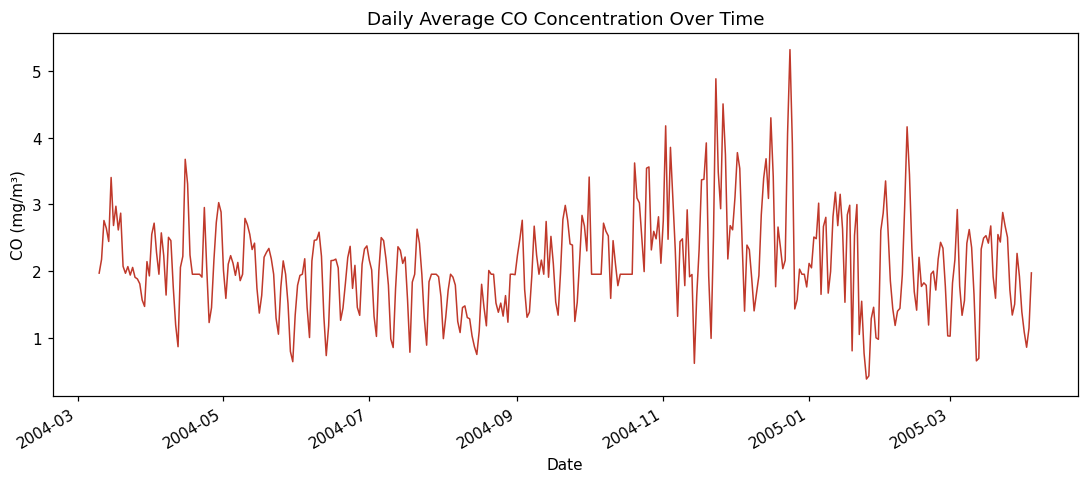

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily_co.index, daily_co.values, color='#c0392b', linewidth=1)
ax.set_title('Daily Average CO Concentration Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('CO (mg/m³)')
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig('../assets/01_co_time_series.png')
plt.show()

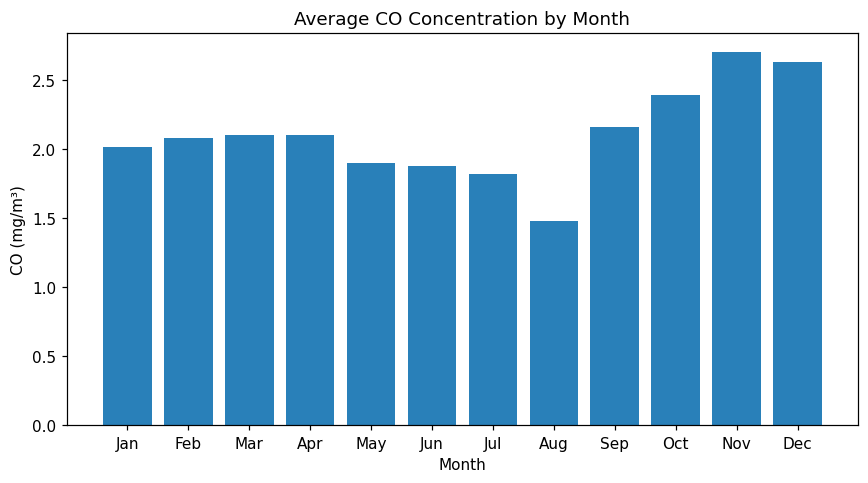

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar([month_names[m-1] for m in monthly_co.index], monthly_co.values, color='#2980b9')
ax.set_title('Average CO Concentration by Month')
ax.set_xlabel('Month')
ax.set_ylabel('CO (mg/m³)')
fig.tight_layout()
fig.savefig('../assets/02_monthly_comparison.png')
plt.show()

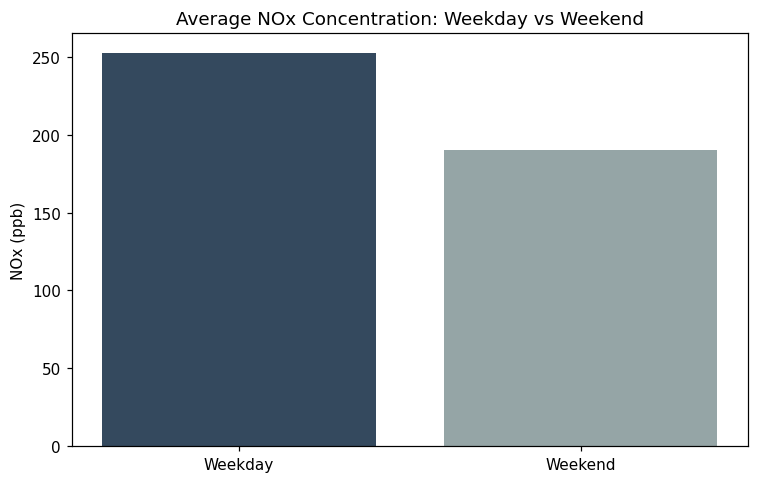

In [22]:
wk = df.groupby('is_weekend')['NOx_GT'].mean()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['Weekday', 'Weekend'], [wk[False], wk[True]], color=['#34495e', '#95a5a6'])
ax.set_title('Average NOx Concentration: Weekday vs Weekend')
ax.set_ylabel('NOx (ppb)')
fig.tight_layout()
fig.savefig('../assets/03_weekday_weekend.png')
plt.show()

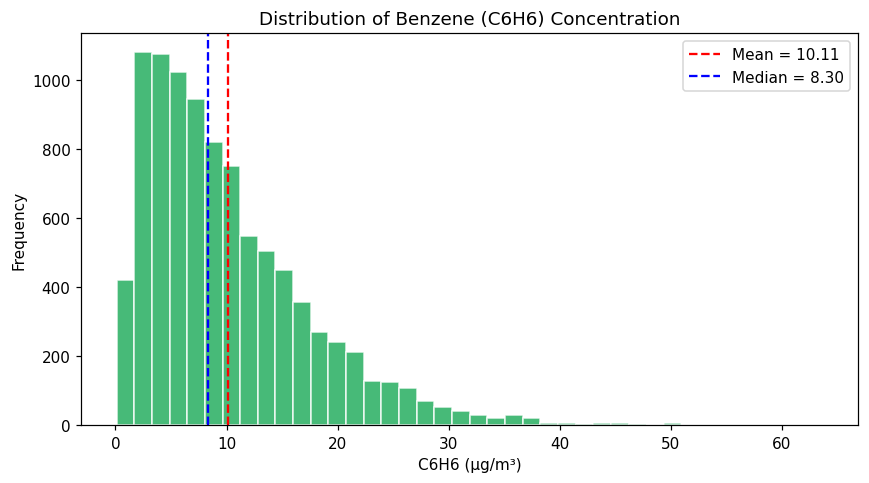

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = df['C6H6_GT'].dropna()
ax.hist(data, bins=40, color='#27ae60', edgecolor='white', alpha=0.85)
ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean = {data.mean():.2f}')
ax.axvline(data.median(), color='blue', linestyle='--', label=f'Median = {data.median():.2f}')
ax.set_title('Distribution of Benzene (C6H6) Concentration')
ax.set_xlabel('C6H6 (µg/m³)')
ax.set_ylabel('Frequency')
ax.legend()
fig.tight_layout()
fig.savefig('../assets/04_histogram_benzene.png')
plt.show()

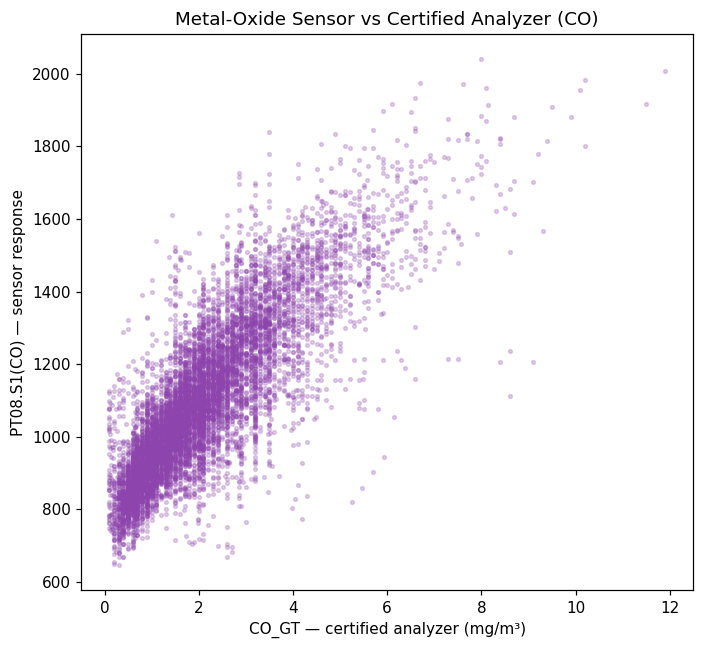

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 6))
valid = df[['PT08_S1_CO', 'CO_GT']].dropna()
ax.scatter(valid['CO_GT'], valid['PT08_S1_CO'], s=6, alpha=0.25, color='#8e44ad')
ax.set_title('Metal-Oxide Sensor vs Certified Analyzer (CO)')
ax.set_xlabel('CO_GT — certified analyzer (mg/m³)')
ax.set_ylabel('PT08.S1(CO) — sensor response')
fig.tight_layout()
fig.savefig('../assets/05_sensor_vs_groundtruth_scatter.png')
plt.show()

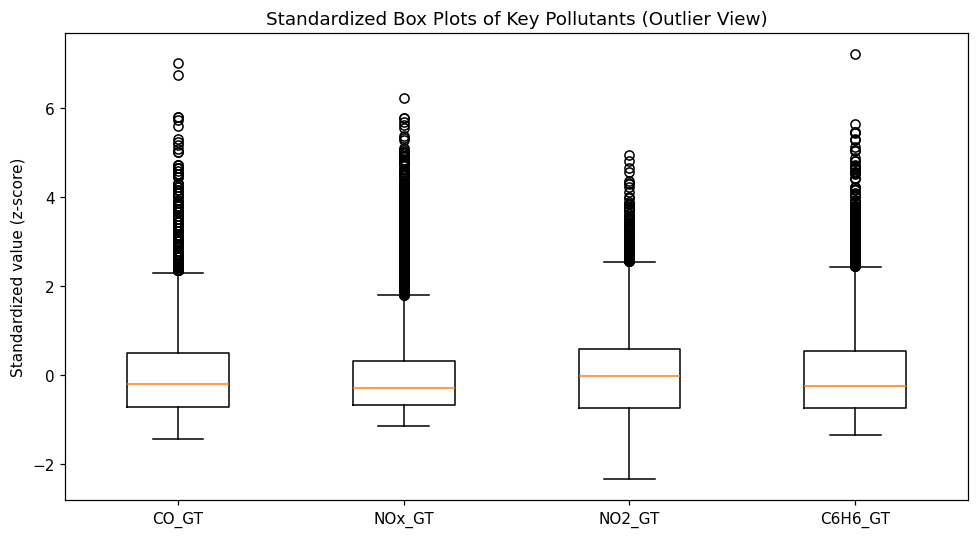

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
cols_box = ['CO_GT', 'NOx_GT', 'NO2_GT', 'C6H6_GT']
standardized = (df[cols_box] - df[cols_box].mean()) / df[cols_box].std()
ax.boxplot([standardized[c].dropna() for c in cols_box], tick_labels=cols_box)
ax.set_title('Standardized Box Plots of Key Pollutants (Outlier View)')
ax.set_ylabel('Standardized value (z-score)')
fig.tight_layout()
fig.savefig('../assets/06_boxplot_outliers.png')
plt.show()

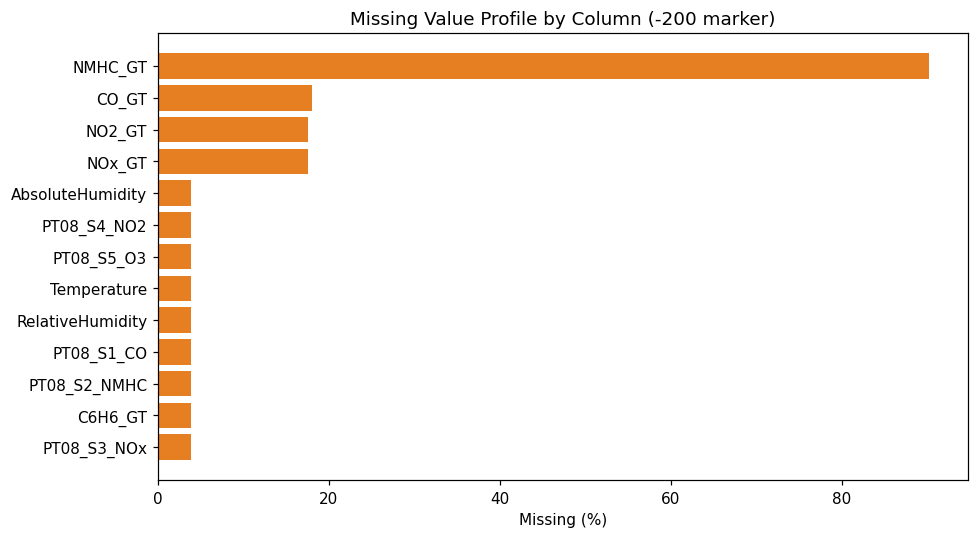

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_pct = (sentinel_counts / len(df) * 100).sort_values()
ax.barh(missing_pct.index, missing_pct.values, color='#e67e22')
ax.set_title('Missing Value Profile by Column (-200 marker)')
ax.set_xlabel('Missing (%)')
fig.tight_layout()
fig.savefig('../assets/07_missing_value_profile.png')
plt.show()

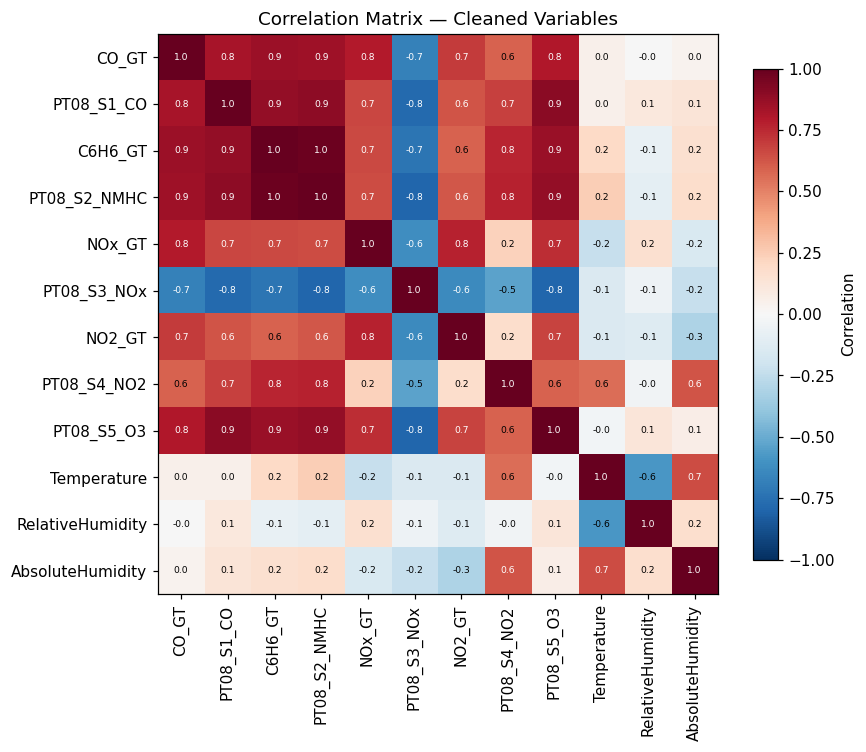

In [27]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(clean_cols))); ax.set_yticks(range(len(clean_cols)))
ax.set_xticklabels(clean_cols, rotation=90); ax.set_yticklabels(clean_cols)
for i in range(len(clean_cols)):
    for j in range(len(clean_cols)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.1f}', ha='center', va='center', fontsize=6,
                color='white' if abs(corr_matrix.values[i,j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Correlation Matrix — Cleaned Variables')
fig.tight_layout()
fig.savefig('../assets/08_correlation_heatmap.png')
plt.show()

## Insights and Limitations

**Key Observations:**

1. CO and NOx show a clear weekday double peak around 08:00 and 18:00-20:00, matching morning and evening commuter traffic.
2. Winter months (Nov, Dec) show noticeably higher CO than summer months (Jun-Aug), likely from heating emissions and cooler air trapping pollutants near ground level.
3. The low-cost metal-oxide CO sensor (PT08.S1) correlates strongly (r ≈ 0.82) with the certified analyzer, confirming it's a usable proxy for CO despite being cheaper hardware.
4. PT08.S3 (NOx sensor) is negatively correlated with almost every other variable (-0.6 to -0.8) — a quirk of that specific sensor's response direction, not a data error.
5. Temperature and humidity barely correlate with pollutant levels (r ≈ 0.05), suggesting traffic patterns, not weather, are the dominant driver of pollution at this site.

**Limitations:**

1. NMHC_GT was ~90% missing and had to be dropped entirely — no conclusions about non-methane hydrocarbons can be drawn from this dataset.
2. Missing values occurred in contiguous blocks (sensor outages), not randomly, so interpolation and hour-of-day medians are reasonable but imperfect substitutes for real readings during those gaps.

In [28]:
df[['Temperature', 'RelativeHumidity', 'CO_GT', 'NOx_GT']].corr()

,Temperature,RelativeHumidity,CO_GT,NOx_GT
Temperature,1.000000,-0.580699,0.048203,-0.233672
RelativeHumidity,-0.580699,1.000000,-0.003252,0.160412
CO_GT,0.048203,-0.003252,1.000000,0.791978
NOx_GT,-0.233672,0.160412,0.791978,1.000000


5. Weather has a mixed relationship with pollution: temperature barely correlates with CO (r ≈ 0.05), but shows a modest negative correlation with NOx (r ≈ -0.23), consistent with cooler, more stagnant air trapping pollutants — reinforcing the earlier finding that winter months have higher CO. Traffic patterns still appear to be the dominant driver overall, given the much stronger hour-of-day and weekday effects.

In [29]:
export_cols = ['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend'] + clean_cols + ['pollution_index']
df[export_cols].to_csv('../data/cleaned_air_quality.csv', index=False)

stats_table.round(3).to_csv('../data/summary_statistics.csv', index=False)

print('Exported cleaned_air_quality.csv with shape:', df[export_cols].shape)
print('Exported summary_statistics.csv with shape:', stats_table.shape)

Exported cleaned_air_quality.csv with shape: (9357, 19)
Exported summary_statistics.csv with shape: (12, 9)


## Conclusion

The raw hourly sensor export was audited, cleaned with a documented, column-specific missing-value strategy, enriched with calendar features and two custom metrics, and explored through 8 visualizations. The dominant pattern is traffic-driven pollution — clear rush-hour peaks, weekday-vs-weekend gaps, and winter-vs-summer differences all point to vehicle emissions and seasonal effects as the main drivers at this site.